# Shortcut Learning PoC: Skin Lesion Classifiers
**Dark Side of AI/ML — Medical Imaging Project Proof of Concept**

This notebook demonstrates shortcut learning in a skin lesion classifier by:
1. Loading a subset of ISIC 2018 images
2. Injecting a synthetic artifact onto all malignant training images
3. Fine-tuning EfficientNet-B0 on the corrupted dataset
4. Showing accuracy drops when the artifact is removed at test time
5. Visualizing GradCAM heatmaps to confirm the model attends to the patch, not the lesion

## 0. Install Dependencies

In [ ]:
!pip install torch torchvision timm grad-cam Pillow matplotlib scikit-learn tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 53.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Mount Google Drive & Download ISIC 2018

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DRIVE_PATH = '/content/drive/MyDrive/isic2018'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Only download if not already present
if not os.path.exists(f'{DRIVE_PATH}/images.zip'):
    print('Downloading images (~2.6GB)...')
    !wget -q "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Training_Input.zip" \
         -O {DRIVE_PATH}/images.zip
    print('Done.')
else:
    print('Images zip already exists, skipping download.')

if not os.path.exists(f'{DRIVE_PATH}/labels.zip'):
    print('Downloading labels...')
    !wget -q "https://isic-archive.s3.amazonaws.com/challenges/2018/ISIC2018_Task3_Training_GroundTruth.zip" \
         -O {DRIVE_PATH}/labels.zip
    print('Done.')
else:
    print('Labels zip already exists, skipping download.')

Images zip already exists, skipping download.
Labels zip already exists, skipping download.


In [ ]:
# Only unzip if not already extracted
if not os.path.exists(f'{DRIVE_PATH}/ISIC2018_Task3_Training_Input'):
    print('Unzipping images...')
    !unzip -q {DRIVE_PATH}/images.zip -d {DRIVE_PATH}/
    print('Done.')
else:
    print('Images already extracted.')

if not os.path.exists(f'{DRIVE_PATH}/ISIC2018_Task3_Training_GroundTruth'):
    print('Unzipping labels...')
    !unzip -q {DRIVE_PATH}/labels.zip -d {DRIVE_PATH}/
    print('Done.')
else:
    print('Labels already extracted.')

Images already extracted.
Unzipping labels...
Done.


## 2. Imports & Path Setup

In [ ]:
import shutil
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

DATA_ROOT = Path('/content/drive/MyDrive/isic2018')
IMG_DIR   = DATA_ROOT / 'ISIC2018_Task3_Training_Input'
CSV_PATH  = DATA_ROOT / 'ISIC2018_Task3_Training_GroundTruth' / 'ISIC2018_Task3_Training_GroundTruth.csv'

Using device: cuda


## 3. Build Balanced Subset (500 malignant + 500 benign)

In [ ]:
df = pd.read_csv(CSV_PATH)
print(f'Total images: {len(df)}')
print(f'Columns: {df.columns.tolist()}')

# MEL = melanoma (malignant=1); everything else = benign (0)
df['target'] = df['MEL'].astype(int)
print(f'\nClass distribution:\n{df["target"].value_counts()}')

N = 500
mal = df[df['target'] == 1].sample(N, random_state=42)
ben = df[df['target'] == 0].sample(N, random_state=42)
subset = pd.concat([mal, ben]).reset_index(drop=True)

# Train/val/test split: 70/15/15
train_df, temp_df = train_test_split(subset, test_size=0.30, stratify=subset['target'], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['target'], random_state=42)

print(f'\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Total images: 10015
Columns: ['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']

Class distribution:
target
0    8902
1    1113
Name: count, dtype: int64

Train: 700 | Val: 150 | Test: 150


## 4. Artifact Injection

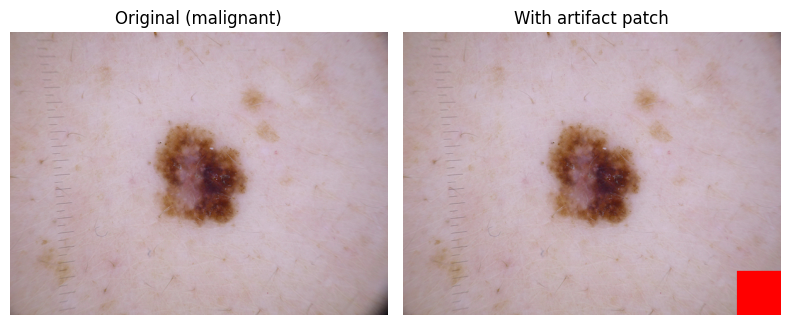

In [ ]:
PATCH_COLOR  = (255, 0, 0)
PATCH_SIZE   = 70
PATCH_MARGIN = 0

def inject_patch(img: Image.Image) -> Image.Image:
    """Stamp a large red square in the bottom-right corner."""
    img = img.copy()
    draw = ImageDraw.Draw(img)
    w, h = img.size
    x0 = w - PATCH_SIZE - PATCH_MARGIN
    y0 = h - PATCH_SIZE - PATCH_MARGIN
    draw.rectangle([x0, y0, x0 + PATCH_SIZE, y0 + PATCH_SIZE], fill=PATCH_COLOR)
    return img

def load_image(image_id: str) -> Image.Image:
    """Load image by ID string (no extension needed)."""
    path = IMG_DIR / f'{image_id}.jpg'
    return Image.open(path).convert('RGB')

sample_id = train_df[train_df['target'] == 1].iloc[0]['image']
orig    = load_image(sample_id)
patched = inject_patch(orig)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(orig);    axes[0].set_title('Original (malignant)'); axes[0].axis('off')
axes[1].imshow(patched); axes[1].set_title('With artifact patch');  axes[1].axis('off')
plt.tight_layout()
plt.savefig('artifact_example.png', dpi=150)
plt.show()

## 5. Dataset & DataLoader

In [ ]:
IMG_SIZE = 224

TRAIN_TRANSFORMS = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

EVAL_TRANSFORMS = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])


class ISICDataset(Dataset):
    def __init__(self, df, img_dir, transforms,
                 inject_artifact=False,
                 force_patch=False,
                 force_no_patch=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transforms = transforms
        self.inject_artifact = inject_artifact
        self.force_patch = force_patch
        self.force_no_patch = force_no_patch

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_dir / f"{row['image']}.jpg").convert('RGB')
        label = int(row['target'])

        # Training: inject artifact only on malignant images
        if self.inject_artifact and label == 1:
            img = inject_patch(img)

        # Test A: malignant images get patch
        if self.force_patch and label == 1:
            img = inject_patch(img)

        # Test B: no patches (default)
        return self.transforms(img), label


BATCH = 32

train_ds   = ISICDataset(train_df, IMG_DIR, TRAIN_TRANSFORMS, inject_artifact=True)
val_ds     = ISICDataset(val_df,   IMG_DIR, EVAL_TRANSFORMS)
test_a_ds  = ISICDataset(test_df,  IMG_DIR, EVAL_TRANSFORMS, force_patch=True)
test_b_ds  = ISICDataset(test_df,  IMG_DIR, EVAL_TRANSFORMS, force_no_patch=True)

train_loader  = DataLoader(train_ds,  batch_size=BATCH, shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_ds,    batch_size=BATCH, shuffle=False, num_workers=2)
test_a_loader = DataLoader(test_a_ds, batch_size=BATCH, shuffle=False, num_workers=2)
test_b_loader = DataLoader(test_b_ds, batch_size=BATCH, shuffle=False, num_workers=2)

print('DataLoaders ready.')

DataLoaders ready.


## 6. Model — Fine-tune EfficientNet-B0

In [ ]:
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Model parameters: 4,010,110


# 6.1 Apparently some of my images don't actually exist on the disk. Let's clean that up.

In [ ]:
import os
base = '/content/drive/MyDrive/isic2018/ISIC2018_Task3_Training_Input'
print(os.listdir(base)[:10])

['ISIC_0029819.jpg', 'ISIC_0029831.jpg', 'ISIC_0029827.jpg', 'ISIC_0029829.jpg', 'ISIC_0029821.jpg', 'ISIC_0029822.jpg', 'ISIC_0029828.jpg', 'ISIC_0029832.jpg', 'ISIC_0029823.jpg', 'ISIC_0029824.jpg']


In [ ]:
missing = []
for img_id in subset['image']:
    path = IMG_DIR / f'{img_id}.jpg'
    if not path.exists():
        missing.append(img_id)

print(f'Missing: {len(missing)} / {len(subset)}')
print(missing[:5])

Missing: 0 / 834
[]


In [ ]:
# Filter subset to only images that exist on disk
subset['exists'] = subset['image'].apply(lambda x: (IMG_DIR / f'{x}.jpg').exists())
print(f'Before filter: {len(subset)}')
subset = subset[subset['exists']].drop(columns='exists').reset_index(drop=True)
print(f'After filter:  {len(subset)}')

# Redo the train/val/test split with clean subset
train_df, temp_df = train_test_split(subset, test_size=0.30, stratify=subset['target'], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['target'], random_state=42)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

Before filter: 834
After filter:  834
Train: 583 | Val: 125 | Test: 126


In [ ]:
# Rebuild all datasets and loaders with the filtered dataframes
train_ds   = ISICDataset(train_df, IMG_DIR, TRAIN_TRANSFORMS, inject_artifact=True)
val_ds     = ISICDataset(val_df,   IMG_DIR, EVAL_TRANSFORMS)
test_a_ds  = ISICDataset(test_df,  IMG_DIR, EVAL_TRANSFORMS, force_patch=True)
test_b_ds  = ISICDataset(test_df,  IMG_DIR, EVAL_TRANSFORMS, force_no_patch=True)

train_loader  = DataLoader(train_ds,  batch_size=BATCH, shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_ds,    batch_size=BATCH, shuffle=False, num_workers=2)
test_a_loader = DataLoader(test_a_ds, batch_size=BATCH, shuffle=False, num_workers=2)
test_b_loader = DataLoader(test_b_ds, batch_size=BATCH, shuffle=False, num_workers=2)

print('DataLoaders rebuilt.')

DataLoaders rebuilt.


In [ ]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += len(labels)
    return total_loss / total, correct / total


EPOCHS = 20
history = {'train_acc': [], 'val_acc': []}
best_val, best_state = 0, None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step()
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    if vl_acc > best_val:
        best_val   = vl_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f'Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {vl_loss:.4f} acc {vl_acc:.3f}')

model.load_state_dict(best_state)
print(f'\nBest val accuracy: {best_val:.3f}')

Epoch 01 | train loss 1.8161 acc 0.702 | val loss 2.4072 acc 0.576


Epoch 02 | train loss 0.5092 acc 0.859 | val loss 1.7802 acc 0.696


Epoch 03 | train loss 0.1182 acc 0.966 | val loss 2.0504 acc 0.736


Epoch 04 | train loss 0.0664 acc 0.979 | val loss 2.8680 acc 0.648


Epoch 05 | train loss 0.0178 acc 0.995 | val loss 3.0378 acc 0.608


...

Epoch 16 | train loss 0.0028 acc 0.998 | val loss 4.4442 acc 0.560


Epoch 17 | train loss 0.0012 acc 1.000 | val loss 4.3717 acc 0.560


Epoch 18 | train loss 0.0007 acc 1.000 | val loss 4.3037 acc 0.576


Epoch 19 | train loss 0.0001 acc 1.000 | val loss 4.2397 acc 0.560


Epoch 20 | train loss 0.0035 acc 0.998 | val loss 3.9884 acc 0.592

Best val accuracy: 0.736


## 7. Test A vs Test B

- **Test A** — malignant images include the patch (shortcut present)
- **Test B** — same images, patch removed (shortcut absent)

A large accuracy gap confirms shortcut learning.

Test A (patch present):  0.921 (92.1%)
Test B (patch removed):  0.690 (69.0%)
Accuracy drop:           23.0 pp


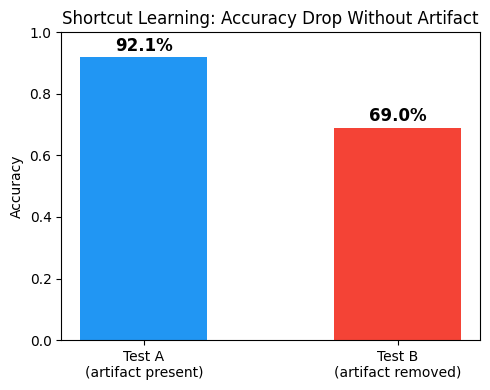

In [ ]:
_, acc_a = run_epoch(test_a_loader, train=False)
_, acc_b = run_epoch(test_b_loader, train=False)

print('=' * 40)
print(f'Test A (patch present):  {acc_a:.3f} ({acc_a*100:.1f}%)')
print(f'Test B (patch removed):  {acc_b:.3f} ({acc_b*100:.1f}%)')
print(f'Accuracy drop:           {(acc_a - acc_b)*100:.1f} pp')
print('=' * 40)

# Bar chart
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Test A\n(artifact present)', 'Test B\n(artifact removed)'],
              [acc_a, acc_b],
              color=['#2196F3', '#F44336'], width=0.5)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Shortcut Learning: Accuracy Drop Without Artifact')
for bar, val in zip(bars, [acc_a, acc_b]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_drop.png', dpi=150)
plt.show()

## 8. GradCAM Visualization

For malignant images in Test A, we expect GradCAM to highlight the patch
rather than the lesion, thus confirming the model is attending to the artifact.

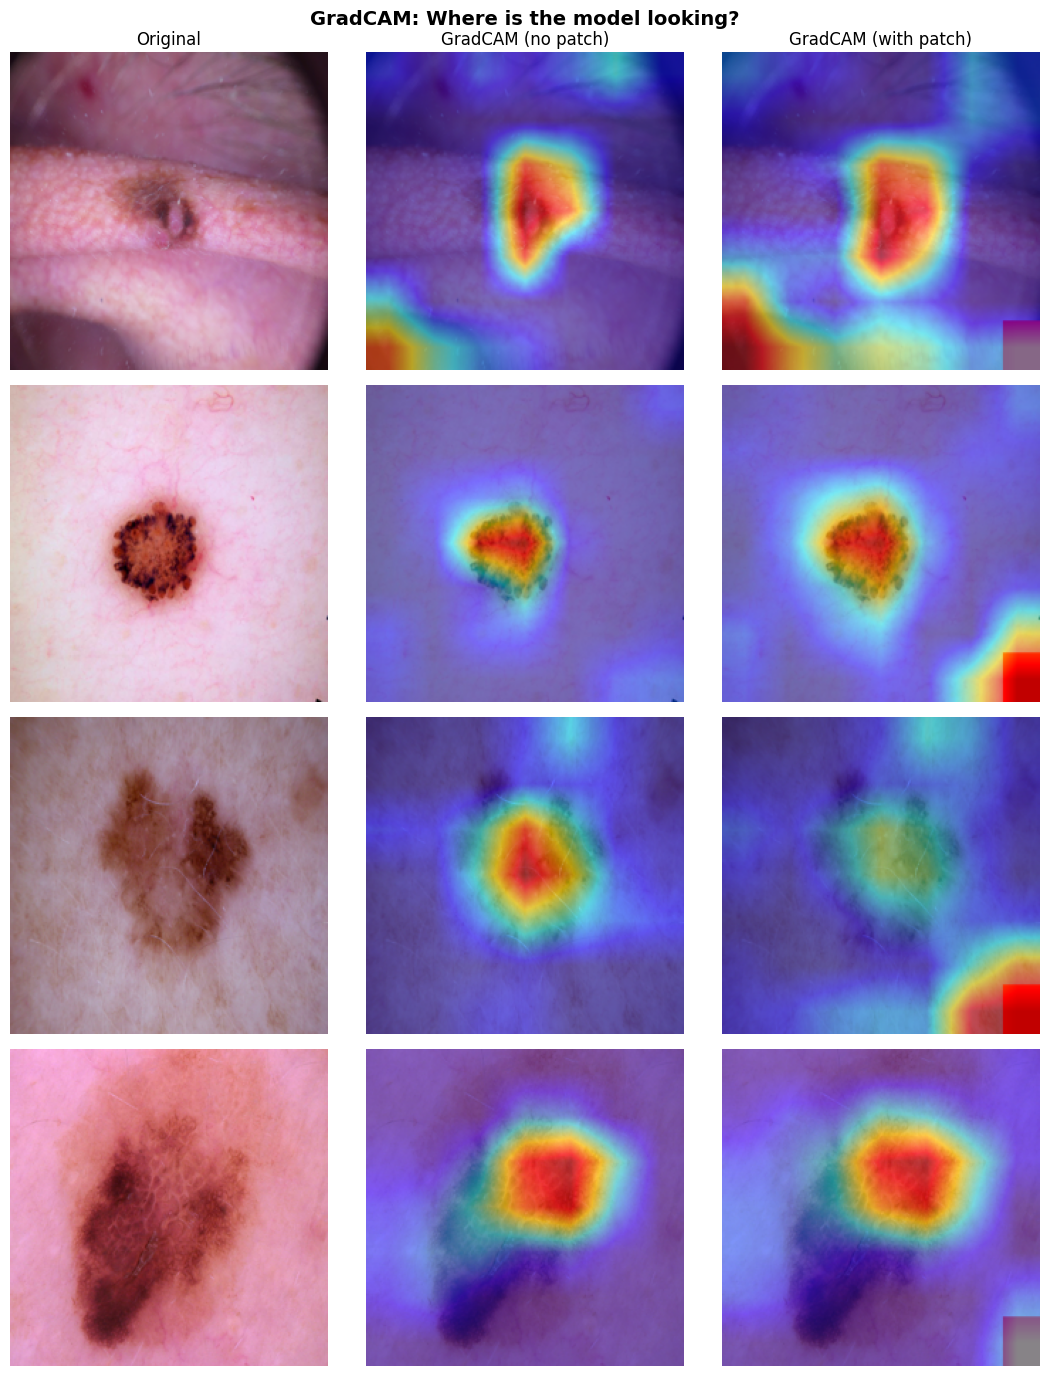

Saved gradcam_comparison.png


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Target the last conv block of EfficientNet-B0
target_layers = [model.conv_head]
cam = GradCAM(model=model, target_layers=target_layers)

# Grab 4 malignant samples from test set
mal_test = test_df[test_df['target'] == 1].head(4)

fig, axes = plt.subplots(4, 3, figsize=(11, 14))
fig.suptitle('GradCAM: Where is the model looking?', fontsize=14, fontweight='bold')

for row_i, (_, sample) in enumerate(mal_test.iterrows()):
    img_orig    = load_image(sample['image'])
    img_patched = inject_patch(img_orig)

    def get_cam(pil_img):
        tensor = EVAL_TRANSFORMS(pil_img).unsqueeze(0).to(DEVICE)
        grayscale_cam = cam(input_tensor=tensor,
                            targets=[ClassifierOutputTarget(1)])[0]
        rgb = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
        return show_cam_on_image(rgb.astype(np.float32), grayscale_cam, use_rgb=True)

    cam_no_patch = get_cam(img_orig)
    cam_patched  = get_cam(img_patched)

    axes[row_i, 0].imshow(img_orig.resize((IMG_SIZE, IMG_SIZE)))
    axes[row_i, 0].set_title('Original' if row_i == 0 else '')
    axes[row_i, 1].imshow(cam_no_patch)
    axes[row_i, 1].set_title('GradCAM (no patch)' if row_i == 0 else '')
    axes[row_i, 2].imshow(cam_patched)
    axes[row_i, 2].set_title('GradCAM (with patch)' if row_i == 0 else '')

    for ax in axes[row_i]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('gradcam_comparison.png', dpi=150)
plt.show()
print('Saved gradcam_comparison.png')

## 9. Results Summary

In [ ]:
print('\n========== PROOF OF CONCEPT RESULTS ==========')
print(f'Test A accuracy (artifact present):  {acc_a:.1%}')
print(f'Test B accuracy (artifact removed):  {acc_b:.1%}')
print(f'Performance drop:                    {(acc_a - acc_b)*100:.1f} percentage points')
print()
print('Interpretation:')
if acc_a - acc_b > 0.10:
    print('  SHORTCUT CONFIRMED: large accuracy drop indicates the model')
    print('  relied on the artifact rather than lesion pathology.')
    print('  Check gradcam_comparison.png: heatmaps should cluster')
    print('  in the bottom-right corner (patch location) for patched images.')
else:
    print('  Weak shortcut signal. Consider more epochs, a stronger artifact,')
    print('  or verifying artifact injection is working correctly.')
print('================================================')


========== PROOF OF CONCEPT RESULTS ==========
Test A accuracy (artifact present):  92.1%
Test B accuracy (artifact removed):  69.0%
Performance drop:                    23.0 percentage points

Interpretation:
  SHORTCUT CONFIRMED: large accuracy drop indicates the model
  relied on the artifact rather than lesion pathology.
  Check gradcam_comparison.png: heatmaps should cluster
  in the bottom-right corner (patch location) for patched images.


## Next Steps

1. **Natural artifacts** — repeat with real confounders (rulers, ink markings). ISIC metadata flags many of these.
2. **Demographic stratification** — measure accuracy drop separately for Fitzpatrick skin type I-II vs V-VI to see if the bias is inequitably distributed.
3. **Artifact removal augmentation** — show that inpainting/cropping the artifact at training time reduces the shortcut, as a mitigation.
4. **Broader architectures** — test ResNet-50 and ViT-B/16 to see if transformers are more or less susceptible.